# 🎯 Session 1 Demo — Adversarial Attacks: Minimum Epsilon Challenge

**Goal:** Use FGSM to fool a CIFAR-10 classifier. The student with the **smallest ε** that still fools ≥ 8/10 images wins.

**Scoring:**
| ε | Points |
|---|--------|
| < 0.01 | 3 pts |
| 0.01 – 0.05 | 2 pts |
| 0.05 – 0.1 | 1 pt |
| ≥ 9/10 fooled | +1 pt bonus |
| Best of session | +1 pt bonus |

Submit your `submission.csv` to the Kaggle competition when done.


In [1]:
# ── Setup ──────────────────────────────────────────────────────
import torch
import torch.nn.functional as F
import numpy as np, pandas as pd, matplotlib.pyplot as plt

DEVICE = (
    "cuda" if torch.cuda.is_available()
    else "mps" if torch.backends.mps.is_available()
    else "cpu"
)
print(f"Running on: {DEVICE}")


ModuleNotFoundError: No module named 'torch'

In [ ]:
# ── Load model (ResNet-20, pretrained on CIFAR-10) ─────────────
model = torch.hub.load(
    'chenyaofo/pytorch-cifar-models', 'cifar10_resnet20',
    pretrained=True, verbose=False
).to(DEVICE).eval()
print("Model loaded ✓")


/usr/local/lib/python3.12/dist-packages/torch/hub.py:247: UserWarning: You are about to download and run code from an untrusted repository. In a future release, this won't be allowed. To add the repository to your trusted list, change the command to load(..., trust_repo=False) and a command prompt will appear asking for an explicit confirmation of trust, or load(..., trust_repo=True), which will assume that the prompt is to be answered with 'yes'. You can also use load(..., trust_repo='check') which will only prompt for confirmation if the repo is not already trusted. This will eventually be the default behaviour
  _check_repo_is_trusted(


Downloading: "https://github.com/chenyaofo/pytorch-cifar-models/zipball/master" to /root/.cache/torch/hub/master.zip
Downloading: "https://github.com/chenyaofo/pytorch-cifar-models/releases/download/resnet/cifar10_resnet20-4118986f.pt" to /root/.cache/torch/hub/checkpoints/cifar10_resnet20-4118986f.pt


100%|██████████| 1.09M/1.09M [00:00<00:00, 7.01MB/s]

Model loaded ✓


In [ ]:
# ── Load images from provided dataset ─────────────────────────
# The instructor pre-selected 10 correctly-classified CIFAR-10 images.
# No internet download needed — just load the file.

data   = torch.load("/kaggle/input/datasets/alexdeonise/mlsp-s1-data/s1_data.pt", weights_only=True)
images  = data["images"].to(DEVICE)
labels  = data["labels"].tolist()
labels_t = torch.tensor(labels).to(DEVICE)
CLASSES  = data["classes"]
mean     = data["mean"]
std      = data["std"]

print(f"Loaded {len(images)} images")
print("True labels:", [CLASSES[l] for l in labels])


Loaded 10 images
True labels: ['cat', 'ship', 'ship', 'airplane', 'frog', 'frog', 'automobile', 'frog', 'cat', 'automobile']


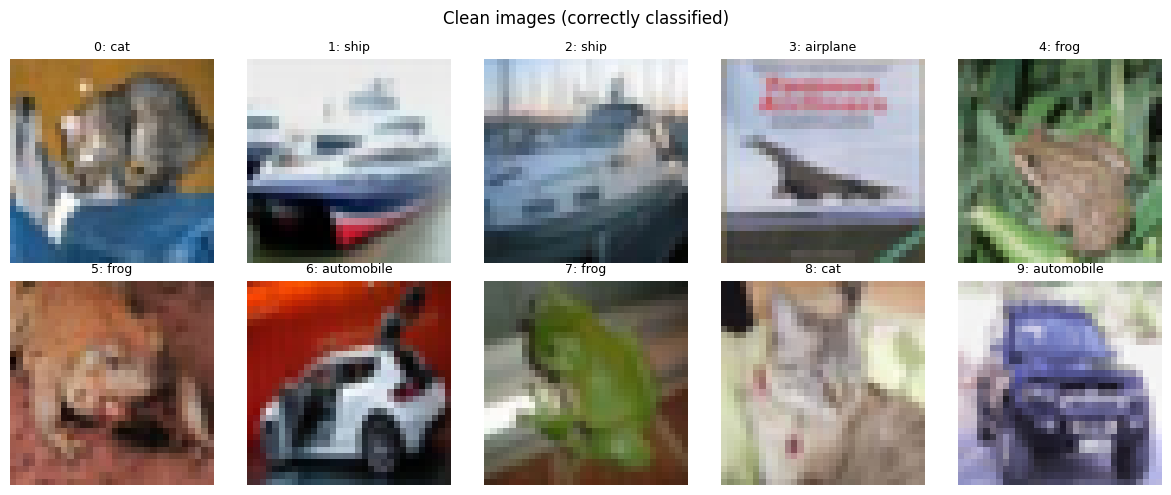

In [ ]:
# ── Visualise the 10 clean images ──────────────────────────────
# mean / std come from s1_data.pt (loaded above)
def denorm(t):
    return (t.cpu() * std.view(3,1,1) + mean.view(3,1,1)).clamp(0, 1)

fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for i, ax in enumerate(axes.flat):
    ax.imshow(denorm(images[i]).permute(1,2,0))
    ax.set_title(f"{i}: {CLASSES[labels[i]]}", fontsize=9)
    ax.axis("off")
plt.suptitle("Clean images (correctly classified)", fontsize=12)
plt.tight_layout(); plt.show()


In [ ]:
# ── FGSM implementation ────────────────────────────────────────
def fgsm_attack(model, images, labels, epsilon):
    """
    Starter version: intentionally weak attack.
    Your job is to fix it.
    """
    imgs = images.clone().detach().requires_grad_(True)

    logits = model(imgs)
    loss = F.cross_entropy(logits, labels)
    loss.backward()

    # TODO: this is NOT a good adversarial attack.
    # It adds random noise, not gradient-based noise.
    # Replace this with the FGSM perturbation.
    perturbation = epsilon * torch.randn_like(imgs)

    adv_images = imgs + perturbation

    # Keep values in a valid normalized CIFAR-10 range
    mean_t = torch.tensor([0.4914, 0.4822, 0.4465], device=images.device).view(1, 3, 1, 1)
    std_t  = torch.tensor([0.2023, 0.1994, 0.2010], device=images.device).view(1, 3, 1, 1)

    lower = (0 - mean_t) / std_t
    upper = (1 - mean_t) / std_t
    adv_images = torch.max(torch.min(adv_images, upper), lower)

    return adv_images.detach()
    
# Quick sanity check at ε = 0.05
adv_test = fgsm_attack(model, images, labels_t, epsilon=0.05)
print(f"ε=0.05 -> {success}/10 images fooled")


ε=0.05 -> 8/10 images fooled


In [ ]:
# ── Find your minimum epsilon ───────────────────────────────────
# Try different values of epsilon and see how few you can use
# while still fooling at least 8 out of 10 images.

YOUR_EPSILON = 0.05   # ← CHANGE THIS — try to make it as small as possible

adv_images = fgsm_attack(model, images, labels_t, YOUR_EPSILON)

with torch.no_grad():
    preds_clean = model(images).argmax(dim=1)
    preds_adv   = model(adv_images).argmax(dim=1)

results = []
for i in range(10):
    fooled = (preds_adv[i] != labels_t[i]).item()
    results.append({
        "image_id":      i,
        "true_label":    CLASSES[labels[i]],
        "pred_clean":    CLASSES[preds_clean[i].item()],
        "pred_adv":      CLASSES[preds_adv[i].item()],
        "fooled":        int(fooled),
        "epsilon":       YOUR_EPSILON,
    })
    status = "✓ FOOLED" if fooled else "✗ still correct"
    print(f"  [{i}] {CLASSES[labels[i]]:12s} → {CLASSES[preds_adv[i].item()]:12s}  {status}")

n_fooled = sum(r["fooled"] for r in results)
print(f"\nResult: {n_fooled}/10 images fooled at ε = {YOUR_EPSILON}")
if n_fooled >= 8:
    print("✓ Qualifies! (≥ 8/10 required)")
else:
    print("✗ Needs ≥ 8/10 — try a slightly larger epsilon.")


  [0] cat          → cat           ✗ still correct
  [1] ship         → ship          ✗ still correct
  [2] ship         → ship          ✗ still correct
  [3] airplane     → ship          ✓ FOOLED
  [4] frog         → frog          ✗ still correct
  [5] frog         → frog          ✗ still correct
  [6] automobile   → automobile    ✗ still correct
  [7] frog         → frog          ✗ still correct
  [8] cat          → cat           ✗ still correct
  [9] automobile   → automobile    ✗ still correct

Result: 1/10 images fooled at ε = 0.05
✗ Needs ≥ 8/10 — try a slightly larger epsilon.


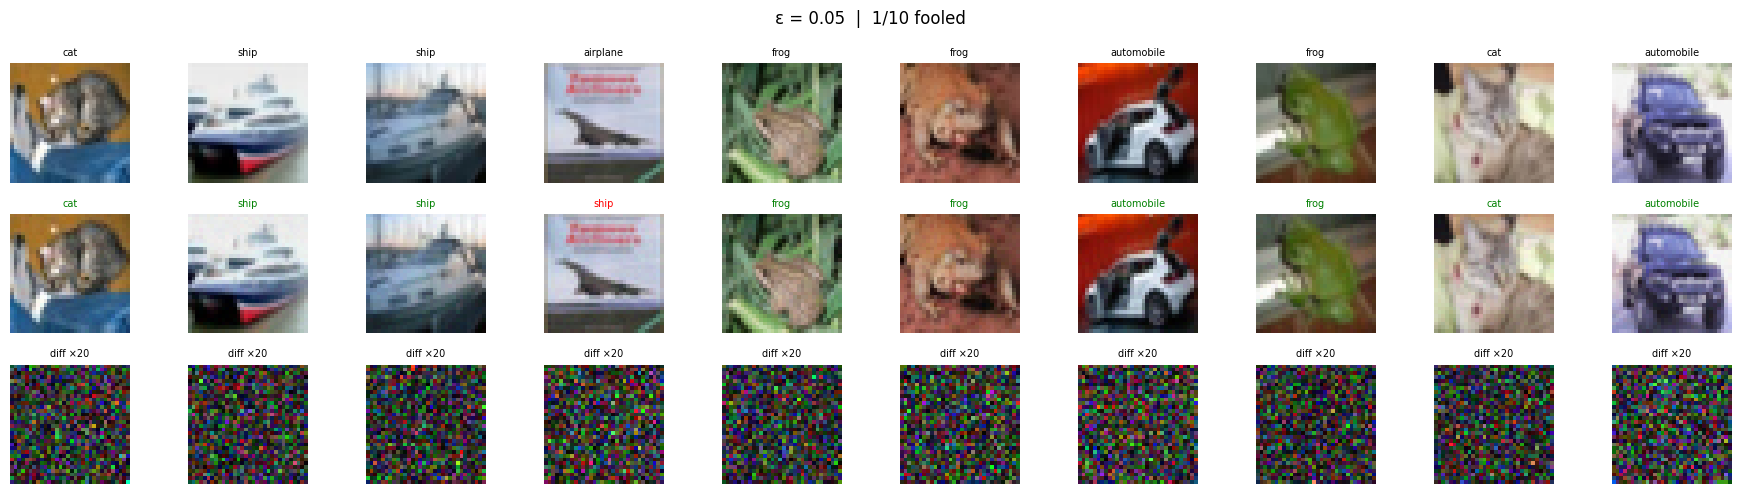

In [ ]:
# ── Visualise adversarial vs clean ─────────────────────────────
fig, axes = plt.subplots(3, 10, figsize=(18, 5))
for i in range(10):
    axes[0, i].imshow(denorm(images[i]).permute(1,2,0))
    axes[0, i].set_title(CLASSES[labels[i]], fontsize=7); axes[0, i].axis("off")

    axes[1, i].imshow(denorm(adv_images[i]).permute(1,2,0))
    axes[1, i].set_title(CLASSES[preds_adv[i].item()], fontsize=7,
                          color="red" if results[i]["fooled"] else "green")
    axes[1, i].axis("off")

    diff = (adv_images[i] - images[i]).abs().cpu().permute(1,2,0).numpy()
    axes[2, i].imshow(diff / diff.max())
    axes[2, i].set_title(f"diff ×{1/YOUR_EPSILON:.0f}", fontsize=7); axes[2, i].axis("off")

axes[0,0].set_ylabel("Original", fontsize=8)
axes[1,0].set_ylabel("Adversarial", fontsize=8)
axes[2,0].set_ylabel("Perturbation", fontsize=8)
plt.suptitle(f"ε = {YOUR_EPSILON}  |  {n_fooled}/10 fooled", fontsize=12)
plt.tight_layout(); plt.show()


In [ ]:
# ── Generate submission ─────────────────────────────────────────
df = pd.DataFrame(results)
df.to_csv("submission.csv", index=False)
print("submission.csv saved:")
print(df[["image_id","true_label","pred_adv","fooled","epsilon"]])
print(f"\n🏆 Your score summary:")
print(f"   ε = {YOUR_EPSILON}")
print(f"   Images fooled: {n_fooled}/10")
if YOUR_EPSILON < 0.01:   pts = 3
elif YOUR_EPSILON < 0.05: pts = 2
elif YOUR_EPSILON < 0.1:  pts = 1
else:                      pts = 0
if n_fooled >= 8:
    print(f"   Base points: {pts}")
    if n_fooled >= 9: print("   Bonus: +1 (≥ 9/10 fooled)")
else:
    print("   ✗ Does not qualify (need ≥ 8/10)")
